# Proyecto de Estadística Multivariada
# Our World in Data CO2 and Greenhouse Gas Emissions dataset

## Librerías

In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 19.5 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import optuna

from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [7]:
df_pca = pd.read_csv('/content/df_pca_saved.csv')

In [8]:
imputer = IterativeImputer(max_iter=10, random_state=42)
predictoras = ['population', 'gdp', 'co2', 'co2_per_capita',
                    'total_ghg', 'coal_co2', 'oil_co2', 'gas_co2',
                    'cement_co2', 'co2_per_gdp', 'energy_per_capita',
                    'cumulative_co2', 'share_global_co2']
df_pca[predictoras] = imputer.fit_transform(df_pca[predictoras])


In [9]:
X = df_pca[predictoras]

pca_scaler = StandardScaler()
X_scaled = pca_scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

## Clustering por país

Anteriormente realizamos PCA sobre nuestros datos debido a la alta correlación y redundancia de las variables originales y encontramos 3 componentes principales que explicaban el mayor porcentaje de variabilidad de nuestros datos; ideal para clustering. Dado que los métodos de clustering se basan en distancias, la multicolinealidad puede afectar en la formación de los grupos, PCA permite transformar en un conjunto reducido de componentes no correlacionados que conserven la variabilidad original de los datos.

Graficamos para ver la estructura de nuestros datos.

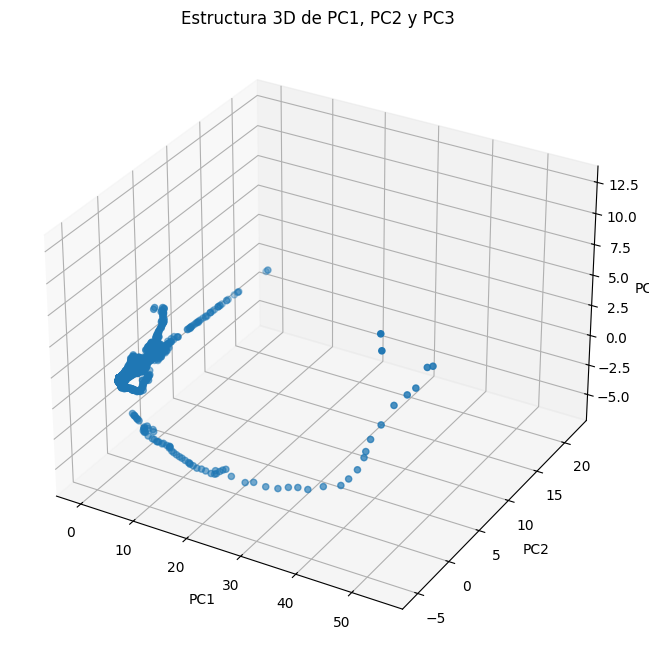

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Estructura 3D de PC1, PC2 y PC3')
plt.show()

In [11]:
# Crear un DataFrame temporal con los componentes principales y las variables
df_pca_interactive = df_pca.copy()
df_pca_interactive['PC1'] = X_pca[:, 0]
df_pca_interactive['PC2'] = X_pca[:, 1]
df_pca_interactive['PC3'] = X_pca[:, 2]

fig = px.scatter_3d(df_pca_interactive,
                    x='PC1',
                    y='PC2',
                    z='PC3',
                    color='development_level',
                    hover_name='country',
                    hover_data=['year', 'co2', 'gdp'], # Información adicional
                    title='Estructura 3D de PC1, PC2 y PC3')

fig.update_layout(scene = dict(
                    xaxis_title='PC1 ', #(Escala Económica y Emisiones Absolutas)
                    yaxis_title='PC2 ', #(Intensidad Per Cápita)
                    zaxis_title='PC3 ')) #(Composición Matriz Energética y Demografía)

fig.show()

De acuerdo con el gráfico 3D los datos presentan una estructura ramificada, alargada y con concentraciones locales. Indicando países con perfiles claramente distintos y una estructura interna definida.

A lo largo del eje PC1 la mayoría de países están cerca del origen y algunos se separan mucho.

- Izquierda → países con un impacto total
- Derecha → grandes emisores globales

PC2 presenta una separación vertical clara; hay países que consumen mucha energía per cápita y países con menor intensidad energética.

PC3 crea ramificaciones, muestra que países con emisiones similares pueden tener perfiles de emisión muy diferentes según sus fuentes de energía.

Este gráfico revela que la estructura de las primeras 3 componentes principales es compleja y no aleatoria, podemos ver una separción natural de los datos y potenciales grupos de países.   


Para este caso es óptimo usar clustering jerárquico y DB-Scan; ya que estos no asumen una forma como K-Means que asume formas esféricas de tamaño similar. Puesto que nuestros datos son ramificados, alargados y con outliers DB-Scan es capaz de encontrar clústers de formas irregulares, además de que los forma de acuerdo a la densidad de los puntos (útil en este caso) y trata outliers de manera óptima.

Por su parte el clústering jerárquico tampoco asume una forma esférica ni necesita un número de clústers de antemano, sino que el dendrograma permite ver las agrupaciones y estas las relaciones y subgrupos dentro de los datos.

Ambos métodos se adaptan a la estructura no esférica de los datos; nos permitirán obtener clústers más acertados y naturales.

### 1. Clústering Jerárquico

Vamos a tomar el último año disponible, 2022 para realizar el clústering, ya que en nuestros dataset hay observaciones a través del tiempo de países. Por lo tanto si hicéramos clústering con todas las observaciones quedarían muchos agrupados en uno solo o un solo clúster para un país.

#### 1. Filtrar datos del último año disponible (2022)

In [12]:
df_year = df_pca[df_pca['year'] == 2024].copy()
print(f"Número de países en {2024}: {len(df_year)}")

# Aplicar el mismo escalado y PCA (pca_scaler de la sección PCA)
X_year = df_year[predictoras]
X_year_scaled = pca_scaler.transform(X_year)
X_pca_year = pca.transform(X_year_scaled)

Número de países en 2024: 68


#### 2. Método del codo

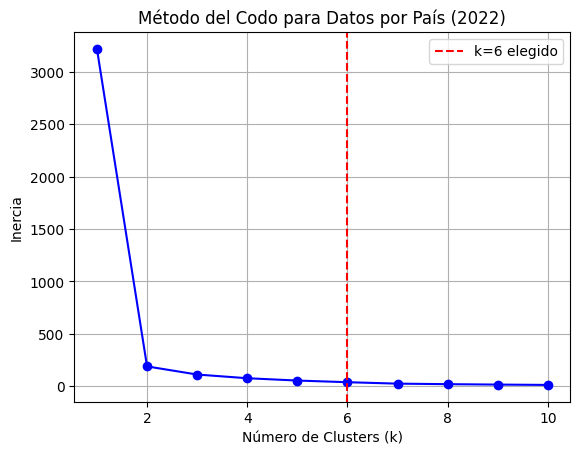

In [14]:
max_k = 10
inertias = []

for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_year)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, max_k + 1), inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Datos por País (2022)')
plt.grid(True)
plt.axvline(x=6, color='r', linestyle='--', label='k=6 elegido')
plt.legend()
plt.show()

Vemos que el codo está en k=4

#### 3. Silhouette Score

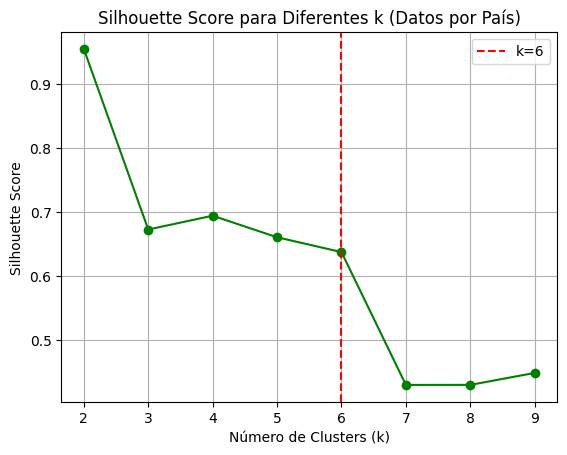

In [15]:
max_k = 9
sil_scores = []
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_year)
    sil = silhouette_score(X_pca_year, labels)
    sil_scores.append(sil)

plt.plot(range(2, max_k + 1), sil_scores, 'go-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para Diferentes k (Datos por País)')
plt.grid(True)
plt.axvline(x=6, color='r', linestyle='--', label='k=6')
plt.legend()
plt.show()

#### 5. Aplicamos clústering

In [17]:
jerarquico_year = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_year = jerarquico_year.fit_predict(X_pca_year)

# Agregar clusters al DataFrame
df_cluster_year = df_year.copy()
df_cluster_year['cluster'] = labels_year

#### 4. Visualización de clusters


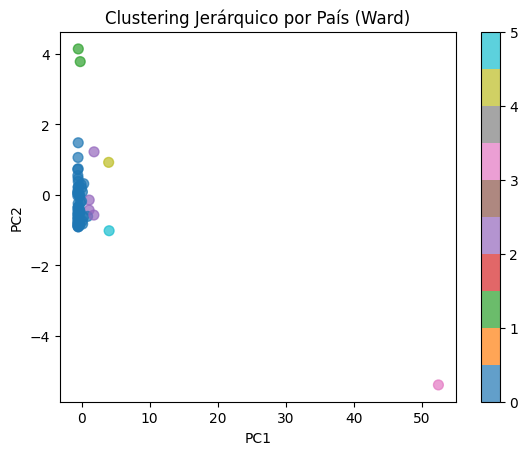

In [18]:
fig, ax = plt.subplots()
scatter = ax.scatter(X_pca_year[:, 0], X_pca_year[:, 1], c=labels_year, cmap='tab10', alpha=0.7, s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Clustering Jerárquico por País (Ward)')
plt.colorbar(scatter)
plt.show()

#### 5. Países por clúster y características promedio

In [19]:
cluster_summary_year = df_cluster_year.groupby('cluster')[predictoras].mean()
display(cluster_summary_year.round(2))

,population,gdp,co2,co2_per_capita,total_ghg,coal_co2,oil_co2,gas_co2,cement_co2,co2_per_gdp,energy_per_capita,cumulative_co2,share_global_co2
cluster,,,,,,,,,,,,,
0,1.522236e+07,1.021984e+11,17.43,3.29,56.12,0.56,9.01,7.07,0.75,0.33,16591.61,1200.10,0.05
1,1.034896e+06,5.708538e+09,25.53,25.16,38.97,1.97,4.26,19.45,0.16,1.82,114215.47,769.98,0.07
2,5.894048e+07,3.998129e+11,253.59,6.17,408.88,39.61,99.84,92.24,11.72,0.20,27501.76,10534.82,0.66
3,1.419321e+09,9.660394e+12,12289.04,8.66,14107.01,8886.02,1705.39,889.41,617.75,-6.57,34514.46,285087.03,31.84
4,3.974243e+07,2.692379e+11,533.34,13.42,802.73,28.67,244.57,233.47,7.30,-0.67,97784.54,35644.13,1.38
5,2.119986e+08,1.441683e+12,483.01,2.28,2804.43,50.95,323.86,58.91,25.38,-0.45,18486.23,18198.71,1.25


In [20]:
print("\nPaíses en cada cluster:")
for i in sorted(df_cluster_year['cluster'].unique()):
    cluster_countries = df_cluster_year[df_cluster_year['cluster'] == i]['country'].tolist()
    print(f"\nCluster {i} ({len(cluster_countries)} países): {', '.join(cluster_countries[:10])}{'...' if len(cluster_countries) > 10 else ''}")


Países en cada cluster:

Cluster 0 (59 países): Afghanistan, Albania, Andorra, Angola, Anguilla, Antarctica, Antigua and Barbuda, Armenia, Aruba, Austria...

Cluster 1 (2 países): Bahrain, Brunei

Cluster 2 (4 países): Algeria, Argentina, Australia, Egypt

Cluster 3 (1 países): China

Cluster 4 (1 países): Canada

Cluster 5 (1 países): Brazil


#### 5. Silhouette Score

In [21]:
sil_score = silhouette_score(X_pca_year, labels_year)
print(f"Silhouette Score: {sil_score:.3f}")

# Valores cercanos a 1 indican clusters bien separados, negativos mal asignados.

Silhouette Score: 0.646


#### 6. Dendrograma y Clústers en espacio PCA

NameError: name 'labels_sklearn' is not defined

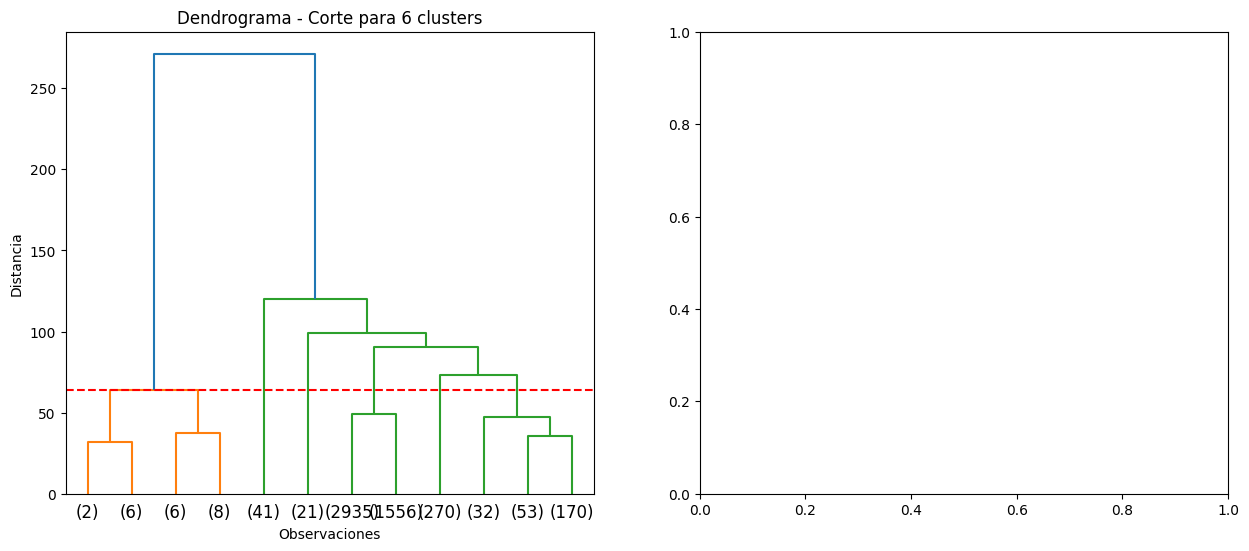

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


# Dendrograma con corte
Z = linkage(X_pca, method='ward', metric='euclidean')
k_optimo = 6

ax1.set_title(f'Dendrograma - Corte para {k_optimo} clusters')
dendrogram(Z, truncate_mode='lastp', p=12, ax=ax1)
ax1.axhline(y=Z[-k_optimo, 2], color='r', linestyle='--')
ax1.set_xlabel('Observaciones')
ax1.set_ylabel('Distancia')

# Clusters en espacio PCA
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_sklearn, cmap='tab10',
                      alpha=0.7, s=50, edgecolor='k')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title(f'Clustering Jerárquico - {k_optimo} Clusters')

# Añadir centroides (para interpretación)
for cluster_id in range(k_optimo):
    cluster_points = X_pca[labels_sklearn == cluster_id]
    centroid = cluster_points.mean(axis=0)
    ax2.scatter(centroid[0], centroid[1],
                color='red', s=200, marker='X',
                edgecolor='black', linewidth=2)

plt.colorbar(scatter, ax=ax2)
plt.tight_layout()
plt.show()

En el dendrograma con encadenamiento 'ward', se hizo el corte en 6 clusters, lo que resulta en grupos más equilibrados y separados, adecuados para la estructura de los datos. En el gráfico de dispersión, los clusters aparecen claramente diferenciados:

- **Cluster 0** (pequeños emisores, 34 países): Agrupa países con emisiones absolutas moderadas y media intensidad, como la mayoría de los países en desarrollo o pequeños, ubicados en la izquierda del gráfico (bajo PC1).

- **Cluster 1** (emisores medios, 181 países): El cluster más grande integradao por la mayoria de píses con emisiones moderadas como Brasil, Canadá, Alemania, Indonesia, Irán, Japón, Arabia Saudita, Reino Unido, etc., con perfiles más bajos o intermedios en escala e intensidad.Lo que indica un impacto climático total bajo.

- **Cluster 2** (Rusia, 1 país): Un cluster separado para Rusia, con altas emisiones absolutas pero perfil específico en composición energética.

- **Cluster 3** (India, 1 país): Un cluster para India, con muy altas emisiones absolutas y alta intensidad per cápita.

- **Cluster 4** (Estados Unidos, 1 país): Un cluster separado para EE.UU., con perfil alto tanto en intensidad como en escala.

- **Cluster 5** (China, 1 país): Un cluster para China, el mayor emisor global, ubicado en la derecha extrema del gráfico (alto PC1 y PC2).

Los centroides marcan los promedios de cada grupo.

PC1 representa la 'Escala de emisiones y actividad económica' (volumen total). Los clústeres más a la derecha en este eje contendrán países con mayores emisiones absolutas y mayor actividad económica. Mientras que a la izquierda estarán los de menor impacto total.

PC2 representa la 'Intensidad de carbono y consumo energético per cápita'. Los clústeres más arriba en este eje agruparán países con mayor intensidad per cápita, y los de abajo, con menor intensidad.

### 2. DB-Scan

#### 1. Definir función objetivo para optuna

In [29]:
def objective(trial):
    eps = trial.suggest_float("eps", 0.5, 5.0)
    min_samples = trial.suggest_int("min_samples", 1, 5)
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca_year)

    # Excluir ruido
    #unique_labels = set(labels)
    #if len(unique_labels) <= 1 or unique_labels == {-1}:
    #    return -1.0

    # Silhouette solo con puntos no ruido
    #mask = labels != -1
    #if mask.sum() < 2:
    #    return -1.0

    mask = labels != -1

    n_clusters = len(set(labels[mask]))

    if n_clusters < 2 or n_clusters >10:
        return -1.0

    score = silhouette_score(X_pca_year[mask], labels[mask])
    return score


#### 2. Ejecutar optuna

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

study.best_params, study.best_value

[I 2026-01-04 15:40:54,081] A new study created in memory with name: no-name-98056009-1a71-40ea-97d1-3202c9d313eb
[I 2026-01-04 15:40:54,084] Trial 0 finished with value: -1.0 and parameters: {'eps': 3.1097086855431115, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,085] Trial 1 finished with value: -1.0 and parameters: {'eps': 1.0156713847917387, 'min_samples': 3}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,087] Trial 2 finished with value: -1.0 and parameters: {'eps': 3.2513584278418524, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,089] Trial 3 finished with value: -1.0 and parameters: {'eps': 4.17140067984614, 'min_samples': 3}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,090] Trial 4 finished with value: -1.0 and parameters: {'eps': 2.6838216901526812, 'min_samples': 5}. Best is trial 0 with value: -1.0.
[I 2026-01-04 15:40:54,092] Trial 5 finished with value: -1.0 and parameters: {'eps': 2.78926

({'eps': 4.837083301877202, 'min_samples': 1}, 0.8725253268534399)

#### 3. DB-Scan con los mejores parámetros

In [ ]:
best_eps = study.best_params["eps"]
best_min_samples = study.best_params["min_samples"]

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples)

labels = dbscan.fit_predict(X_pca_year)

df_cluster_year['cluster_dbscan'] = labels

#### 4. Visulización de clústers

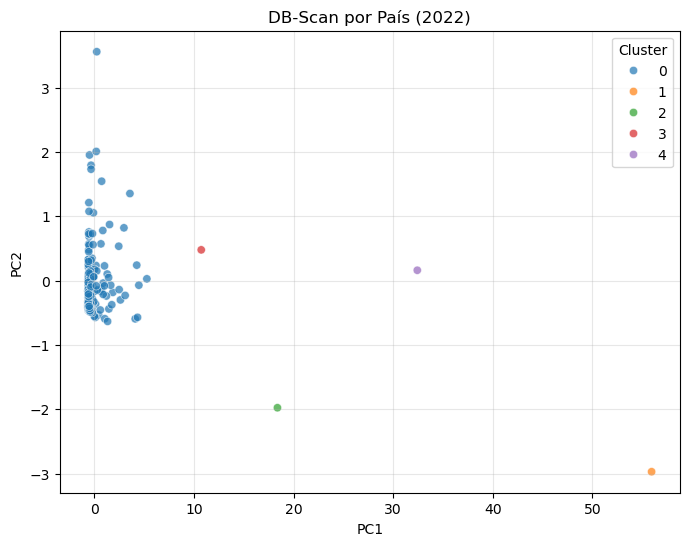

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
temp_df_year = pd.DataFrame({
    'PC1': X_pca_year[:, 0],
    'PC2': X_pca_year[:, 1],
#    'PC3': X_pca_year[:, 2],
    'cluster': labels
})
sns.scatterplot(data=temp_df_year, x='PC1', y='PC2', hue='cluster', palette="tab10", alpha=0.7)
plt.title("DB-Scan por País (2022)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

#### 5. Análisis de clústers  

In [ ]:
unique_labels_year, counts_year = np.unique(labels, return_counts=True)
print("Clusters encontrados por DB-Scan (2022):")
for label, count in zip(unique_labels_year, counts_year):
    if label == -1:
        print(f"Ruido: {count} países")
    else:
        print(f"Cluster {label}: {count} países")

# Países únicos
for label in unique_labels_year:
    if label == -1:
        cluster_countries = df_cluster_year[df_cluster_year['cluster_dbscan'] == label]['country'].unique()[:5].tolist()
        print(f"\nRuido (ejemplos): {', '.join(cluster_countries)}")
    else:
        cluster_countries = df_cluster_year[df_cluster_year['cluster_dbscan'] == label]['country'].unique()[:5].tolist()
        print(f"\nCluster {label} (ejemplos): {', '.join(cluster_countries)}")

Clusters encontrados por DB-Scan (2022):
Cluster 0: 215 países
Cluster 1: 1 países
Cluster 2: 1 países
Cluster 3: 1 países
Cluster 4: 1 países

Cluster 0 (ejemplos): Afghanistan, Albania, Algeria, Andorra, Angola

Cluster 1 (ejemplos): China

Cluster 2 (ejemplos): India

Cluster 3 (ejemplos): Russia

Cluster 4 (ejemplos): United States


#### Interpretación DB-Scan por País (2022)

Aplicando DB-Scan a los datos de 2022 por país (igual que el clustering jerárquico), muestra un cluster principal que agrupa a 215 países, los cuales comparten patrones similares en las variables analizadas con PCA. Está compuesto mayoritariamente por países con perfiles económicos, demográficos y de emisiones comparables.

Se identifican cuatro clusters individuales, cada uno formado por un solo país: China, India, Rusia y Estados Unidos: esto tiene sentido ya que son outliers y presentan niveles muy altos de emisiones, población, etc.

Esto complementa el clustering jerárquico, confirmando la separación de grandes emisores como ruido/outliers.